<a href="https://colab.research.google.com/github/Takshshah-16/Big_Mart_Sales_Prediction/blob/main/Store_Sales_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing dependencies

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn import metrics
from sklearn.preprocessing import LabelEncoder

Loading the dataset using pandas

In [39]:
big_mart_data= pd.read_csv("/content/Train.csv")

In [40]:
big_mart_data.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


Now we need to preprocess as our dataset has lot of text values and hence when we use ml model we cannot feed text or string data we have to categorize it

In [41]:
big_mart_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


There are missing values in features:


*   Item_Weight
*   Outlet_Size



There are categorical features:

*   Item_Identifier
*   Item_Fat_Content


*   Item_type
*   Outlet_Identifier

*   Outlet_Size

*   Outlet_Location_Type
*   Outlet_Type








In [42]:
big_mart_data.isnull().sum()

,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


Item Weight has 1463 missing values and Outlet Size has 2410 missing values

In [43]:
#starting with handling missing values

In [44]:
print(big_mart_data['Item_Weight'])

0        9.300
1        5.920
2       17.500
3       19.200
4        8.930
         ...  
8518     6.865
8519     8.380
8520    10.600
8521     7.210
8522    14.800
Name: Item_Weight, Length: 8523, dtype: float64


In [ ]:
#Since the feature is numeric we can take mean and replace the missing values with that mean

In [45]:
big_mart_data['Item_Weight'].mean()

np.float64(12.857645184135976)

In [46]:
big_mart_data["Item_Weight"].fillna(big_mart_data["Item_Weight"].mean(),inplace=True)

/tmp/ipykernel_1073/2661088028.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  big_mart_data["Item_Weight"].fillna(big_mart_data["Item_Weight"].mean(),inplace=True)


In [47]:
big_mart_data.isnull().sum()

,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


In [48]:
#so we have dealt with the missing values of Item Weight

In [49]:
#now we shall focus on removing the missing values from outlet_size

In [51]:
big_mart_data['Outlet_Size']

,Outlet_Size
0,Medium
1,Medium
2,Medium
3,NaN
4,High
...,...
8518,High
8519,NaN
8520,Small
8521,Medium


In [52]:
#here we have text data so we canniot compute mean so we shall use mode and we will be using mode

In [53]:
mode_of_outlet_size=big_mart_data.pivot_table(values='Outlet_Size',columns='Outlet_Type', aggfunc=(lambda x:x.mode()[0]))
print(mode_of_outlet_size)

Outlet_Type Grocery Store Supermarket Type1 Supermarket Type2  \
Outlet_Size         Small             Small            Medium   

Outlet_Type Supermarket Type3  
Outlet_Size            Medium  


In [54]:
missing_values=big_mart_data['Outlet_Size'].isnull()

In [55]:
big_mart_data.loc[missing_values,'Outlet_Size']=big_mart_data.loc[missing_values,'Outlet_Type'].apply(lambda x:mode_of_outlet_size)

In [56]:
big_mart_data.isnull().sum()

,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,0
Outlet_Location_Type,0


In [57]:
#now we have removed the missing values from outlet_size as well

Data exploration and analysis

In [58]:
#stastical attributes

In [59]:
big_mart_data.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,8523.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.226124,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,9.310000,0.026989,93.826500,1987.000000,834.247400
50%,12.857645,0.053931,143.012800,1999.000000,1794.331000
75%,16.000000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


Data Analysis of the entire dataset

In [ ]:
#numerical attributes

In [60]:
sns.set()

/tmp/ipykernel_1073/2221220577.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(big_mart_data['Item_Weight'])


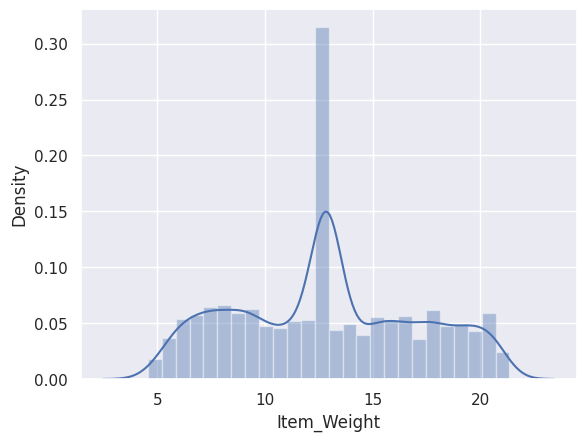

In [61]:
plt.figsize=(6,6)
sns.distplot(big_mart_data['Item_Weight'])
plt.show()

/tmp/ipykernel_1073/121350560.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(big_mart_data['Item_Visibility'])


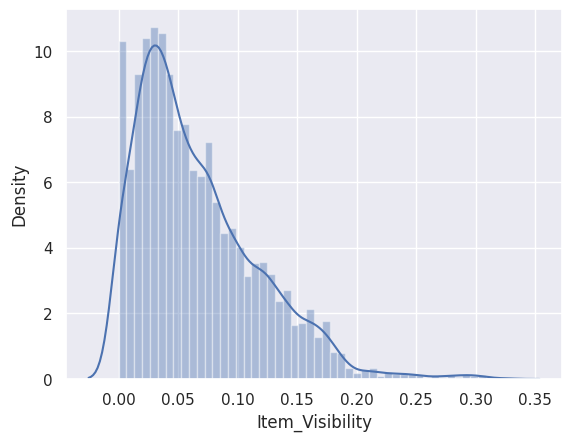

In [62]:
plt.figsize=(6,6)
sns.distplot(big_mart_data['Item_Visibility'])
plt.show()

/tmp/ipykernel_1073/1005736670.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(big_mart_data['Item_MRP'])


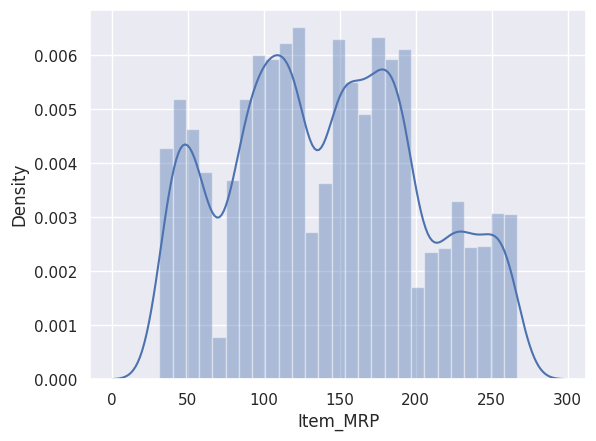

In [63]:
plt.figsize=(6,6)
sns.distplot(big_mart_data['Item_MRP'])
plt.show()

/tmp/ipykernel_1073/1715678859.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(big_mart_data['Item_Outlet_Sales'])


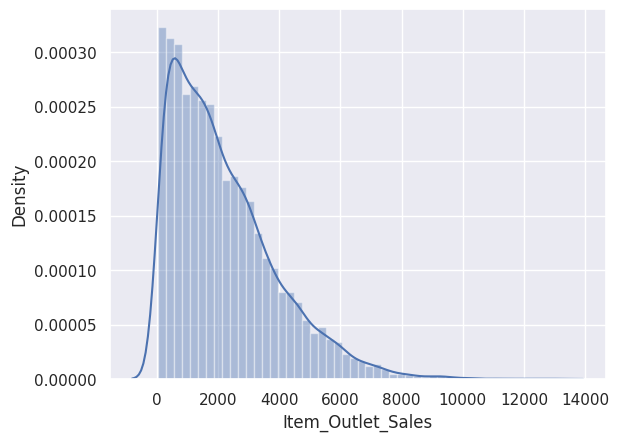

In [64]:
plt.figsize=(6,6)
sns.distplot(big_mart_data['Item_Outlet_Sales'])
plt.show()

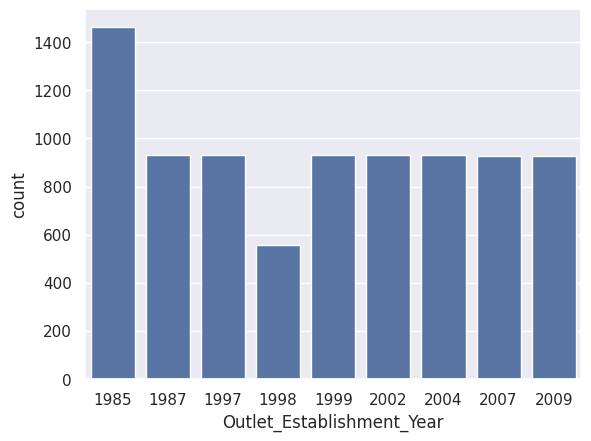

In [65]:
plt.figsize=(6,6)
sns.countplot(x="Outlet_Establishment_Year", data=big_mart_data)
plt.show()

In [66]:
#similar analysis for categorical variables with different plots

In [67]:
#Now focus on preprocessing and encoding categorical to numerical attributes for running the ML Model

In [68]:
#value counts function tells us the number of values for each category within a feature

In [69]:
big_mart_data["Item_Fat_Content"].value_counts()

,count
Item_Fat_Content,
Low Fat,5089
Regular,2889
LF,316
reg,117
low fat,112


In [70]:
#here we repalced lf and reg ti just 2 categories to reduce dimensionality

In [71]:
big_mart_data["Item_Fat_Content"].replace({"LF":"Low Fat","low fat":"Low Fat","reg":"Regular"},inplace=True)

/tmp/ipykernel_1073/1736821863.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  big_mart_data["Item_Fat_Content"].replace({"LF":"Low Fat","low fat":"Low Fat","reg":"Regular"},inplace=True)


In [72]:
big_mart_data["Item_Fat_Content"].value_counts()

,count
Item_Fat_Content,
Low Fat,5517
Regular,3006


In [73]:
encoder=LabelEncoder()

There are categorical features:

Item_Identifier

Item_Fat_Content

Item_type

Outlet_Identifier

Outlet_Size

Outlet_Location_Type

Outlet_Type

In [74]:
big_mart_data["Item_Identifier"]=encoder.fit_transform(big_mart_data["Item_Identifier"])
big_mart_data["Item_Fat_Content"]=encoder.fit_transform(big_mart_data["Item_Fat_Content"])
big_mart_data["Item_Type"]=encoder.fit_transform(big_mart_data["Item_Type"])
big_mart_data["Outlet_Identifier"]=encoder.fit_transform(big_mart_data["Outlet_Identifier"])
big_mart_data["Outlet_Size"]=encoder.fit_transform(big_mart_data["Outlet_Size"].astype(str))
big_mart_data["Outlet_Location_Type"]=encoder.fit_transform(big_mart_data["Outlet_Location_Type"])
big_mart_data["Outlet_Type"]=encoder.fit_transform(big_mart_data["Outlet_Type"])

In [75]:
big_mart_data.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,156,9.30,0,0.016047,4,249.8092,9,1999,1,0,1,3735.1380
1,8,5.92,1,0.019278,14,48.2692,3,2009,1,2,2,443.4228
2,662,17.50,0,0.016760,10,141.6180,9,1999,1,0,1,2097.2700
3,1121,19.20,1,0.000000,6,182.0950,0,1998,2,2,0,732.3800
4,1297,8.93,0,0.000000,9,53.8614,1,1987,0,2,1,994.7052


In [76]:

#we have converted all the attributes to categorical values and we can now fit this data to the model

In [77]:
X= big_mart_data.drop(columns="Item_Outlet_Sales",axis=1)
Y= big_mart_data["Item_Outlet_Sales"]

In [78]:
print(X)
print(Y)

      Item_Identifier  Item_Weight  Item_Fat_Content  Item_Visibility  \
0                 156        9.300                 0         0.016047   
1                   8        5.920                 1         0.019278   
2                 662       17.500                 0         0.016760   
3                1121       19.200                 1         0.000000   
4                1297        8.930                 0         0.000000   
...               ...          ...               ...              ...   
8518              370        6.865                 0         0.056783   
8519              897        8.380                 1         0.046982   
8520             1357       10.600                 0         0.035186   
8521              681        7.210                 1         0.145221   
8522               50       14.800                 0         0.044878   

      Item_Type  Item_MRP  Outlet_Identifier  Outlet_Establishment_Year  \
0             4  249.8092                  9    

In [80]:
X_test, X_train, Y_test, Y_train=train_test_split(X,Y, test_size=0.2, random_state=2)


In [81]:
print(X.shape, X_train.shape, X_test.shape)

(8523, 11) (1705, 11) (6818, 11)


In [82]:
regressor=XGBRegressor()

In [83]:
regressor.fit(X_train,Y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [84]:
training_prediction=regressor.predict(X_train)

In [85]:
print(training_prediction)

[1613.3461 5892.1484 1110.197  ... 1901.5574 3135.736  5208.369 ]


In [86]:
#now time to evaluate our model by finding r^2 error, mean absolute error

In [87]:
r2_training=metrics.r2_score(Y_train,training_prediction)

In [88]:
print(r2_training)

0.9799364221890273


In [90]:
regressor.fit(X_test,Y_test)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [91]:
testing_prediction=regressor.predict(X_test)

In [92]:
r2_testing=metrics.r2_score(Y_test,testing_prediction)

In [93]:
print(r2_testing)

0.879565708425905
